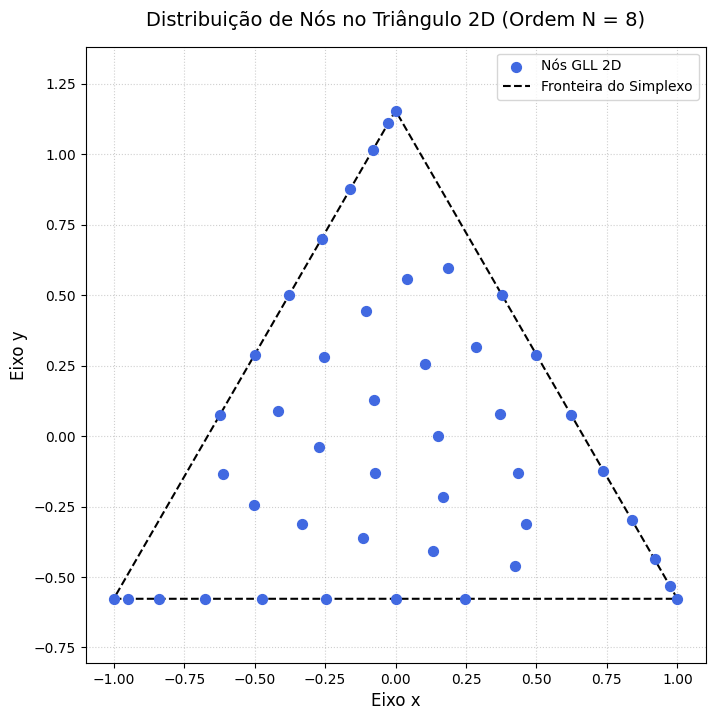

O número de condição corrigido (N=8) é: 4617.31


In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
from scipy.special import gamma

import operadores2D as op2D
import triangulo_ref as tref

# Supondo que as funções Warpfactor(N, rout) e Nodes2D(N) já estejam definidas

# 1. Definir a ordem do polinômio e gerar os nós
N = 8 
x, y = tref.Nodes2D(N)

# 2. Configurar a figura
plt.figure(figsize=(8, 8))

# 3. Plotar os pontos (nós)
plt.scatter(x, y, color='royalblue', s=50, zorder=3, label='Nós GLL 2D')

# 4. Desenhar o contorno do triângulo equilátero de referência
# Os vértices no método de Hesthaven são: (-1, -1/√3), (1, -1/√3) e (0, 2/√3)
v_x = [-1, 1, 0, -1]
v_y = [-1/np.sqrt(3), -1/np.sqrt(3), 2/np.sqrt(3), -1/np.sqrt(3)]
plt.plot(v_x, v_y, 'k--', linewidth=1.5, zorder=2, label='Fronteira do Simplexo')

# 5. Formatação do gráfico
plt.title(f'Distribuição de Nós no Triângulo 2D (Ordem N = {N})', fontsize=14, pad=15)
plt.xlabel('Eixo x', fontsize=12)
plt.ylabel('Eixo y', fontsize=12)

# axis('equal') é crucial para que o triângulo não fique esticado e pareça equilátero
plt.axis('equal') 
plt.grid(True, linestyle=':', alpha=0.6, zorder=1)
plt.legend(loc='upper right')

# 6. Exibir o gráfico
plt.show()



# 1. Gera nós no triângulo visual (Equilátero)
x, y = tref.Nodes2D(N)

# 2. Mapeia para o triângulo matemático (Retângulo de Referência)
r, s = tref.xytors(x, y)

# 3. Agora sim, gera a Matriz de Vandermonde usando (r,s)
# (A função Vandermonde2D vai chamar a rstoab lá dentro com segurança)
V2D = tref.Vandermonde2D(N, r, s)

# 4. Calcula o número de condição
kappa = np.linalg.cond(V2D)
print(f"O número de condição corrigido (N={N}) é: {kappa:.2f}")